# Uygulamalı İstatistik Dersi 2025-2026

31 Ekim 2025 | 7. Hafta


[![Google Colab'de Aç](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mertssmnoglu/R/blob/main/uygulamali_istatistik_2025-2026/2025-10-31_uygulamali_istatistik_w7/2025-10-31_uygulamali_istatistik_w7.ipynb)


**Konu Başlıkları**

## Normallik Varsayımı

Örneklem varsayımı ve hipotez testi olmazsa olmazı varsayımlar

serbestlik derecesi düzeltmesi

Normallik varsayımı öyle değil analiz yaptığımız değişkenin kendi bazında normallik göstermesi gerekir.

İki grubun verilerinin de normal dağılması gerekir. 3 grup varsa yine aynı.

Eğer bunlar yoksa parametrik olmayan alternatiflere yöneliriz.

### Parametrik Olan ve Parametrik Olmayan Testler

| Parametrik Testler             | Parametrik Olmayan Testler      |
| ------------------------------ | ------------------------------- |
| Tek örneklem t testi           | Wilcoxon İşaretli Sıralar Testi |
| Bağımsız iki örneklem t testi  | Mann-Whitney U Testi            |
| Tek yönlü ANOVA                | Kruskal-Wallis Testi            |
| İki yönlü ANOVA                | Friedman Testi                  |
| Pearson Korelasyon             | Spearman Korelasyon             |
| -                              | Ki-Kare Testi                   |

## F Testi

Model anlamlılığı testi.

## Ki Kare Testi

Kategorik değişkenlerde kullanılır. Ki kare testi parametrik olmayan bir testtir.

---

## Mann Whitney U Testi

Mann Whitney U testi, Kruskal Wallis testi verilerin sıra değerleri kullanır.

---

## Örneklem Varsayımı

1. Veriler birbirinden bağımsızdır.
2. Örneklem rastgele seçilmiştir.

## Normallik Varsayımı İçin Kullanılan Yöntemler

1. Histogram Grafiği
2. Kutu - Çizgi Grafiği
3. Q-Q Plot, P-P Plot
4. Dal Yaprak Grafiği
5. Kolmogorov-Smirnov Testi
6. Shapiro-Wilk Testi



## Hipotezler

H0: Veriler normal dağılıyor.\
H1: Veriler normal dağılmıyor.

p degeri <= 0.05 ise H0 reddedilir.

p degeri > 0.05 ise H0 reddedilemez.

In [1]:
# help(shapiro.test) # Shapiro-Wilk Testi
# help(ks.test) # Kolmogorov-Smirnov Testi

In [2]:
set.seed(4)

In [3]:
hipo <- rnorm(100, 5, 1)
shapiro.test(hipo)

hip <- rnorm(100, 6, 2)
ks.test(hipo, hip)
cat(">>> p değerine bakıldığında bu iki veri setinin benzer olmadığı sonucuna varılır.")


	Shapiro-Wilk normality test

data:  hipo
W = 0.98686, p-value = 0.4283



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  hipo and hip
D = 0.35, p-value = 9.57e-06
alternative hypothesis: two-sided


>>> p değerine bakıldığında bu iki veri setinin benzer olmadığı sonucuna varılır.

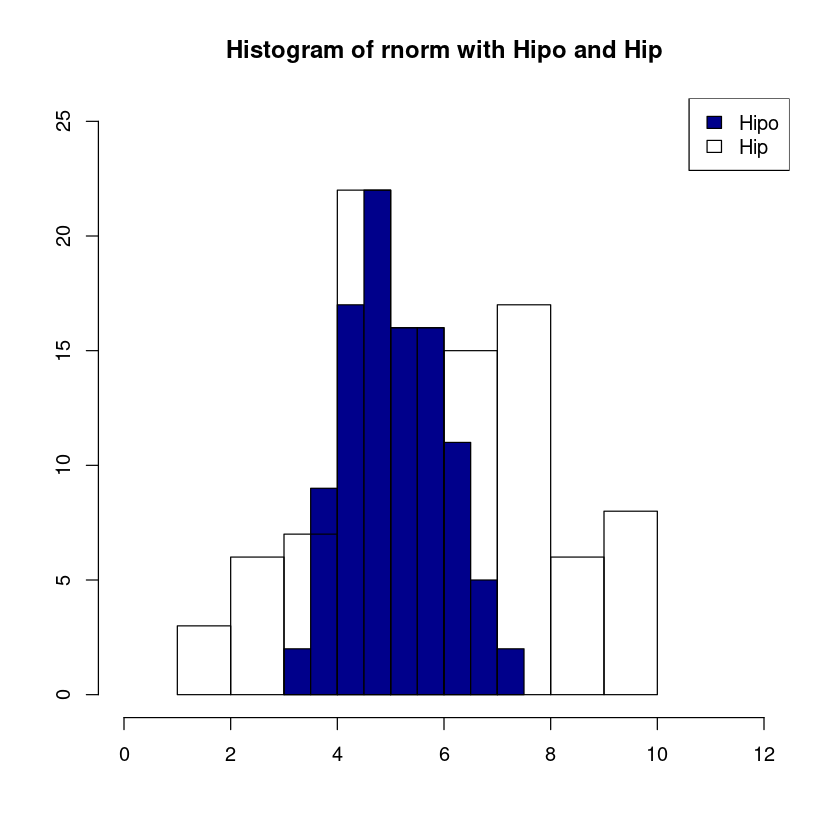

In [4]:
minx <- min(c(hipo, hip))
maxx <- max(c(hipo, hip))

hist(
    hipo,
    main="Histogram of rnorm with Hipo and Hip",
    xlab="",
    ylab="",
    col="darkblue",
    xlim = c(0, 12),
    ylim = c(0, 25)
)
hist(
    hip,
    xlab="",
    ylab="",
    col="transparent",
    add=TRUE # Üst üste ekleme
)

legend("topright", legend=c("Hipo", "Hip"), fill=c("darkblue", "transparent"))

# Tek Örneklem T Testi

Aynı ortalamayı sahip olup olmadığını incelemek istiyorsak tek örneklem T testi yapılır.

H0: Mü eşittir x ortalama\
H1: Mü büyüktür x ortalama (*tek yönlü sağ*)\
H1: Mü küçüktür x ortalama (*tek yönlü sol*)\
H1: Mü eşit değildir x ortalama (*çift yönlü*)

## Örnek

Türkiyedeki gençlerin sosyal medya kullanma oranı %70, ticaret üniversitesinden de 100 tane rastgele öğrenci seçip bu oranı %67.
Buna göre türkiyedeki sosyal medya kullanma oranı ile ticaret üniversitesindeki gençlerin sosyal medya kullanma oranı arasında fark var mıdır?

H0: Türkiyedeki gençlerin sosyal medya kullanma oranı ile ticaret üniversitesindeki gençlerin sosyal medya kullanma oranı arasında fark yoktur.\
H1: Türkiyedeki gençlerin sosyal medya kullanma oranı ile ticaret üniversitesindeki gençlerin sosyal medya kullanma oranı arasında fark vardır.

In [5]:
# help("t.test") # T Testi

In [6]:
# 4.5 ile karşılaştırma
t.test(
    hipo,
    alternative = "two.sided",
    mu = 4.5, # anakütle ortalaması
)




	One Sample t-test

data:  hipo
t = 6.5274, df = 99, p-value = 2.881e-09
alternative hypothesis: true mean is not equal to 4.5
95 percent confidence interval:
 4.915193 5.277857
sample estimates:
mean of x 
 5.096525 


Serbestlik Derecesi(df) = n - 1 = 100 - 1 = 99

---

Evren ortalaması ile örneklem ortalaması karşılaştırılmıştır. Buna göre H0 hipotezi reddedilmiştir. (t_99 = 6.53; p < 0.001).

Elde edilen sonuca göre **ortalamalar birbirinden farklıdır**.

In [7]:
# 4.9 ile karşılaştırma
t.test(
    hipo,
    alternative = "two.sided",
    mu = 4.9
)


	One Sample t-test

data:  hipo
t = 2.1505, df = 99, p-value = 0.03395
alternative hypothesis: true mean is not equal to 4.9
95 percent confidence interval:
 4.915193 5.277857
sample estimates:
mean of x 
 5.096525 


Evren ortalaması ile örneklem ortalaması karşılaştırılmıştır. Buna göre H0 hipotezi reddedilmiştir. (t_99 = 6.53; p = 0.03395).

Elde edilen sonuca göre **ortalamalar birbirinden farklıdır**.

In [8]:
# 4.9 ile karşılaştırma
t.test(
    hipo,
    alternative = "two.sided",
    mu = 4.95
)


	One Sample t-test

data:  hipo
t = 1.6033, df = 99, p-value = 0.112
alternative hypothesis: true mean is not equal to 4.95
95 percent confidence interval:
 4.915193 5.277857
sample estimates:
mean of x 
 5.096525 


Evren ortalaması ile örneklem ortalaması karşılaştırılmıştır. Buna göre H0 hipotezi reddedilmiştir. (t_99 = 6.53; p = 0.112).

Elde edilen sonuca göre **ortalamalar birbirinden farklı değildir**.

#### 1. Yol

In [9]:
xort <- 46.2
mu <- 48.5
s <- 4
n <- 30

# t = (X̄ - μ) / (s / √n)
t <- (xort - mu) / (s / sqrt(n))
t

[1] -3.149405

In [10]:
alpha <- .05
t.tablo <- qt(1 - alpha/2, df = n - 1)
c(-t.tablo, t.tablo)

[1] -2.04523  2.04523

#### 2. Yol

In [11]:
pdegeri <- 2 * pt(t, df = n - 1)
pdegeri

[1] 0.003774928